# 🎧 Spotify Listening Data Analysis

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## Project Overview

This project analyzes Spotify streaming history to understand listening behavior and music preferences.

### Objectives
- Clean and prepare Spotify streaming data
- Analyze listening trends over time
- Identify top artists, tracks, and albums
- Analyze listening duration and playback behavior
- Understand platform, shuffle, and skip behavior
- Identify peak listening hours
- Present findings through clear visualizations

> **Note:** This is a Python-based data analysis project. No GenAI component is included.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [3]:
df = pd.read_csv("spotify_history.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (149860, 11)


,spotify_track_uri,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped
0,2J3n32GeLmMjwuAzyhcSNe,08-07-2013 2.44,web player,3185,"Say It, Just Say It",The Mowgli's,Waiting For The Dawn,autoplay,clickrow,False,False
1,1oHxIPqJyvAYHy0PVrDU98,08-07-2013 2.45,web player,61865,Drinking from the Bottle (feat. Tinie Tempah),Calvin Harris,18 Months,clickrow,clickrow,False,False
2,487OPlneJNni3NWC8SYqhW,08-07-2013 2.50,web player,285386,Born To Die,Lana Del Rey,Born To Die - The Paradise Edition,clickrow,unknown,False,False
3,5IyblF777jLZj1vGHG2UD3,08-07-2013 2.52,web player,134022,Off To The Races,Lana Del Rey,Born To Die - The Paradise Edition,trackdone,clickrow,False,False
4,0GgAAB0ZMllFhbNc3mAodO,08-07-2013 3.17,web player,0,Half Mast,Empire Of The Sun,Walking On A Dream,clickrow,nextbtn,False,False


## 3. Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149860 entries, 0 to 149859
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   spotify_track_uri  149860 non-null  object
 1   ts                 149860 non-null  object
 2   platform           149860 non-null  object
 3   ms_played          149860 non-null  int64 
 4   track_name         149860 non-null  object
 5   artist_name        149860 non-null  object
 6   album_name         149860 non-null  object
 7   reason_start       149717 non-null  object
 8   reason_end         149743 non-null  object
 9   shuffle            149860 non-null  bool  
 10  skipped            149860 non-null  bool  
dtypes: bool(2), int64(1), object(8)
memory usage: 10.6+ MB


In [5]:
df.describe(include="all")

,spotify_track_uri,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped
count,149860,149860,149860,1.498600e+05,149860,149860,149860,149717,149743,149860,149860
unique,16527,95738,6,NaN,13838,4113,7946,13,15,2,2
top,1BLOVHYYlH4JUHQGcpt75R,27-07-2017 20.11,android,NaN,Ode To The Mets,The Beatles,The Beatles,trackdone,trackdone,True,False
freq,207,209,139821,NaN,207,13621,2063,76655,77194,111583,141991
mean,NaN,NaN,NaN,1.283166e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,1.178401e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,2.795000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,1.388400e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2.185070e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nPlatforms:")
print(df["platform"].value_counts())

print("\nShuffle:")
print(df["shuffle"].value_counts())

print("\nSkipped:")
print(df["skipped"].value_counts())

Missing values:
spotify_track_uri      0
ts                     0
platform               0
ms_played              0
track_name             0
artist_name            0
album_name             0
reason_start         143
reason_end           117
shuffle                0
skipped                0
dtype: int64

Duplicate rows:
1782

Platforms:
platform
android           139821
cast to device      3898
iOS                 3049
windows             1691
mac                 1176
web player           225
Name: count, dtype: int64

Shuffle:
shuffle
True     111583
False     38277
Name: count, dtype: int64

Skipped:
skipped
False    141991
True       7869
Name: count, dtype: int64


## 4. Data Cleaning

In [8]:
# Create a working copy
clean_df = df.copy()

# Remove exact duplicate rows
duplicate_count = clean_df.duplicated().sum()
clean_df = clean_df.drop_duplicates().copy()

# Clean text columns
text_columns = [
    "spotify_track_uri", "platform", "track_name",
    "artist_name", "album_name", "reason_start", "reason_end"
]

for col in text_columns:
    clean_df[col] = clean_df[col].astype("string").str.strip()

# Fill missing playback reasons
clean_df["reason_start"] = clean_df["reason_start"].fillna("unknown")
clean_df["reason_end"] = clean_df["reason_end"].fillna("unknown")

# Convert timestamp
clean_df["ts"] = pd.to_datetime(
    clean_df["ts"],
    format="%d-%m-%Y %H.%M",
    errors="coerce"
)

# Ensure numeric duration
clean_df["ms_played"] = pd.to_numeric(clean_df["ms_played"], errors="coerce")

# Create duration in minutes
clean_df["duration_minutes"] = clean_df["ms_played"] / 60000

# Remove rows with invalid timestamps
clean_df = clean_df.dropna(subset=["ts"]).copy()

# Feature engineering
clean_df["year"] = clean_df["ts"].dt.year
clean_df["month"] = clean_df["ts"].dt.month
clean_df["month_name"] = clean_df["ts"].dt.month_name()
clean_df["day_of_week"] = clean_df["ts"].dt.day_name()
clean_df["hour"] = clean_df["ts"].dt.hour

print("Original records:", len(df))
print("Duplicate records removed:", duplicate_count)
print("Clean records:", len(clean_df))
print("Remaining missing values:", clean_df.isnull().sum().sum())

Original records: 149860
Duplicate records removed: 1782
Clean records: 148078
Remaining missing values: 0


## 5. Data Quality Checks

In [9]:
print("Date range:")
print("First listening:", clean_df["ts"].min())
print("Last listening:", clean_df["ts"].max())

print("\nYears covered:")
print(clean_df["year"].min(), "to", clean_df["year"].max())

print("\nDuration summary:")
print(clean_df["duration_minutes"].describe())

print("\nZero-duration records:")
zero_count = (clean_df["ms_played"] == 0).sum()
print(zero_count)
print(f"{zero_count / len(clean_df) * 100:.2f}%")

Date range:
First listening: 2013-07-08 02:44:00
Last listening: 2024-12-15 23:06:00

Years covered:
2013 to 2024

Duration summary:
count    148078.000000
mean          2.137404
std           1.963246
min           0.000000
25%           0.046983
50%           2.310308
75%           3.640496
max          26.018750
Name: duration_minutes, dtype: float64

Zero-duration records:
3396
2.29%


## 6. KPI Summary

In [10]:
total_records = len(clean_df)
unique_artists = clean_df["artist_name"].nunique()
unique_tracks = clean_df["track_name"].nunique()
unique_albums = clean_df["album_name"].nunique()
total_hours = clean_df["duration_minutes"].sum() / 60
average_play_minutes = clean_df["duration_minutes"].mean()
skip_rate = clean_df["skipped"].mean() * 100

print("Total Listening Records:", f"{total_records:,}")
print("Unique Artists:", f"{unique_artists:,}")
print("Unique Tracks:", f"{unique_tracks:,}")
print("Unique Albums:", f"{unique_albums:,}")
print("Total Listening Hours:", round(total_hours, 2))
print("Average Play Duration:", round(average_play_minutes, 2), "minutes")
print("Skip Rate:", round(skip_rate, 2), "%")

Total Listening Records: 148,078
Unique Artists: 4,113
Unique Tracks: 13,838
Unique Albums: 7,946
Total Listening Hours: 5275.04
Average Play Duration: 2.14 minutes
Skip Rate: 5.31 %


## 7. Listening Trends by Year

In [11]:
yearly_listening = clean_df["year"].value_counts().sort_index()

yearly_hours = (
    clean_df.groupby("year")["duration_minutes"]
    .sum()
    .div(60)
    .round(2)
)

display(yearly_listening)
display(yearly_hours)

year
2013      185
2014       23
2015     2804
2016     6401
2017    25937
2018    14765
2019    14719
2020    23274
2021    22955
2022    16123
2023    11022
2024     9870
Name: count, dtype: int64

year
2013      7.83
2014      1.04
2015     59.25
2016    196.88
2017    666.14
2018    472.42
2019    476.39
2020    868.00
2021    890.23
2022    639.10
2023    515.06
2024    482.71
Name: duration_minutes, dtype: float64

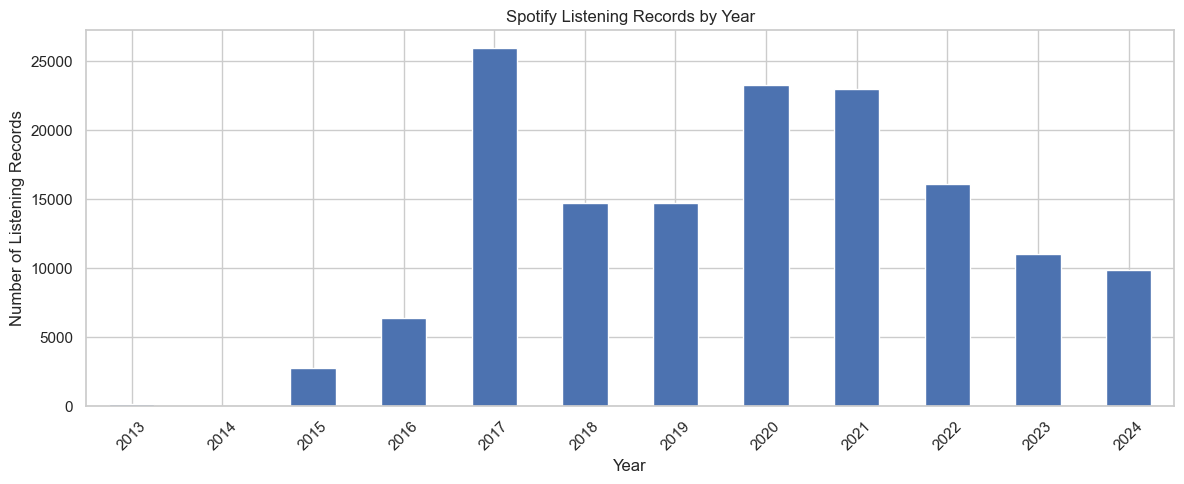

In [12]:
plt.figure(figsize=(12, 5))
yearly_listening.plot(kind="bar")
plt.title("Spotify Listening Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Listening Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

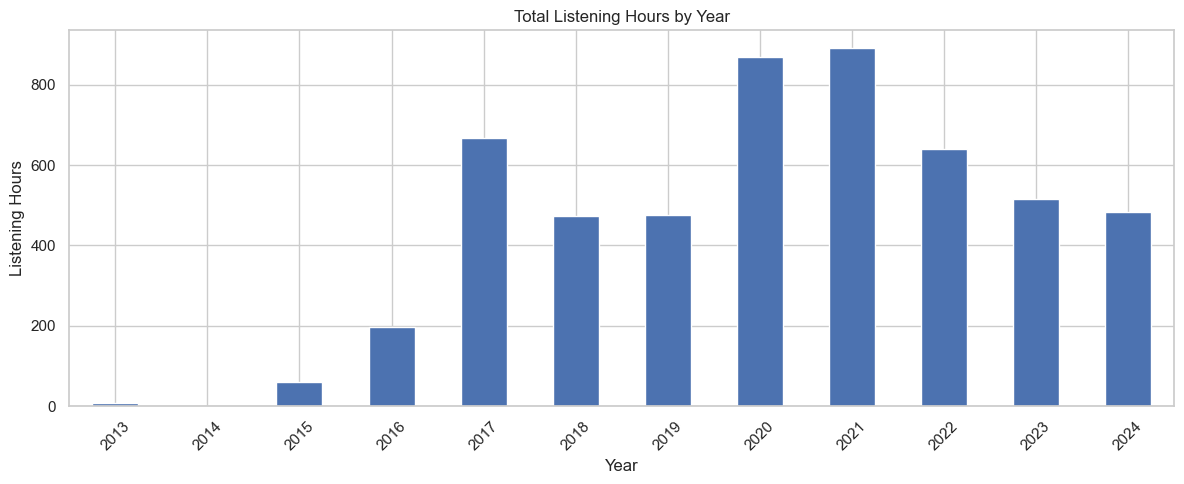

In [13]:
plt.figure(figsize=(12, 5))
yearly_hours.plot(kind="bar")
plt.title("Total Listening Hours by Year")
plt.xlabel("Year")
plt.ylabel("Listening Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Top Artists

In [14]:
top_artists = (
    clean_df.groupby("artist_name")
    .agg(
        listening_records=("artist_name", "size"),
        total_minutes=("duration_minutes", "sum")
    )
    .sort_values("listening_records", ascending=False)
    .head(10)
)

top_artists

,listening_records,total_minutes
artist_name,,
The Beatles,13479,19930.352533
The Killers,6714,17159.771017
John Mayer,4769,11792.159050
Bob Dylan,3776,9339.461917
Paul McCartney,2675,5895.606733
Led Zeppelin,2461,4088.258450
Johnny Cash,2456,3952.644083
The Rolling Stones,2360,5028.045233
Radiohead,2287,3567.799900


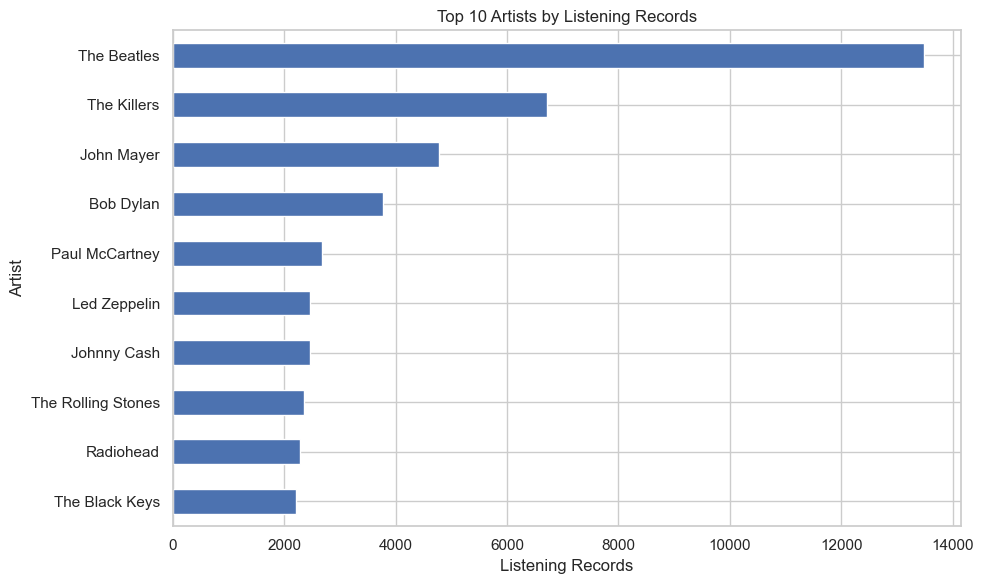

In [15]:
plt.figure(figsize=(10, 6))
top_artists["listening_records"].sort_values().plot(kind="barh")
plt.title("Top 10 Artists by Listening Records")
plt.xlabel("Listening Records")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()

## 9. Top Tracks

In [16]:
top_tracks = (
    clean_df.groupby(["track_name", "artist_name"])
    .agg(
        listening_records=("track_name", "size"),
        total_minutes=("duration_minutes", "sum")
    )
    .sort_values("listening_records", ascending=False)
    .head(10)
)

top_tracks

,,listening_records,total_minutes
track_name,artist_name,,
Ode To The Mets,The Strokes,203,1100.407200
In the Blood,John Mayer,180,636.390350
Dying Breed,The Killers,165,598.944333
Caution,The Killers,153,551.107650
19 Dias y 500 Noches - En Directo,Joaquín Sabina,146,706.250450
Concerning Hobbits,Howard Shore,141,317.736367
All These Things That I've Done,The Killers,134,560.731633
Come Together - Remastered 2009,The Beatles,133,373.508517
Yesterday - Remastered 2009,The Beatles,132,244.714017


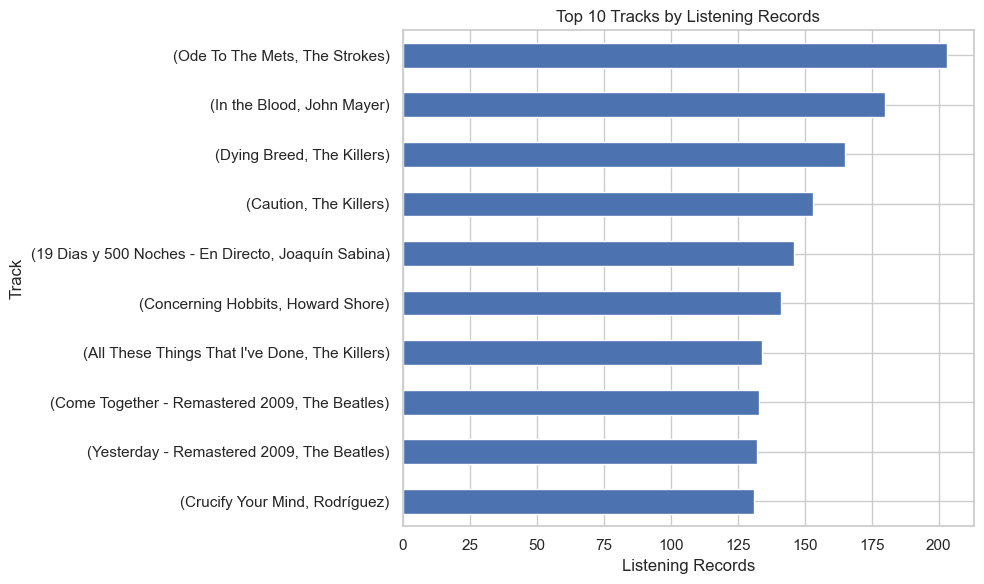

In [17]:
plt.figure(figsize=(10, 6))
top_tracks["listening_records"].sort_values().plot(kind="barh")
plt.title("Top 10 Tracks by Listening Records")
plt.xlabel("Listening Records")
plt.ylabel("Track")
plt.tight_layout()
plt.show()

## 10. Top Albums

In [18]:
top_albums = (
    clean_df.groupby("album_name")
    .agg(
        listening_records=("album_name", "size"),
        total_minutes=("duration_minutes", "sum")
    )
    .sort_values("listening_records", ascending=False)
    .head(10)
)

top_albums

,listening_records,total_minutes
album_name,,
The Beatles,2038,3074.933050
Past Masters,1664,2406.763817
Abbey Road,1413,2463.188650
The Wall,1214,2297.236833
Revolver,1027,1443.423050
Help!,966,1416.291583
At Folsom Prison,910,1492.152083
Sgt. Pepper's Lonely Hearts Club Band,904,1564.717067
Exile On Main Street,880,1779.198250


## 11. Listening Duration Analysis

In [19]:
duration_stats = clean_df["duration_minutes"].describe()

print(duration_stats)

median_duration = clean_df["duration_minutes"].median()
print("\nMedian listening duration:", round(median_duration, 2), "minutes")

count    148078.000000
mean          2.137404
std           1.963246
min           0.000000
25%           0.046983
50%           2.310308
75%           3.640496
max          26.018750
Name: duration_minutes, dtype: float64

Median listening duration: 2.31 minutes


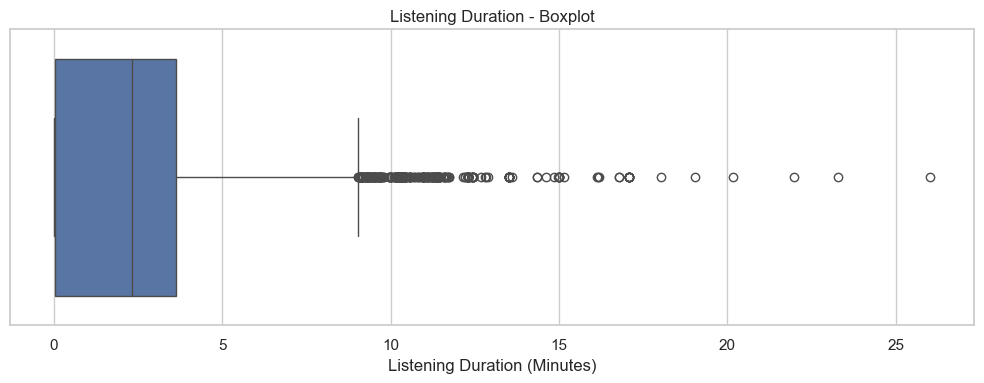

In [20]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=clean_df["duration_minutes"])
plt.title("Listening Duration - Boxplot")
plt.xlabel("Listening Duration (Minutes)")
plt.tight_layout()
plt.show()

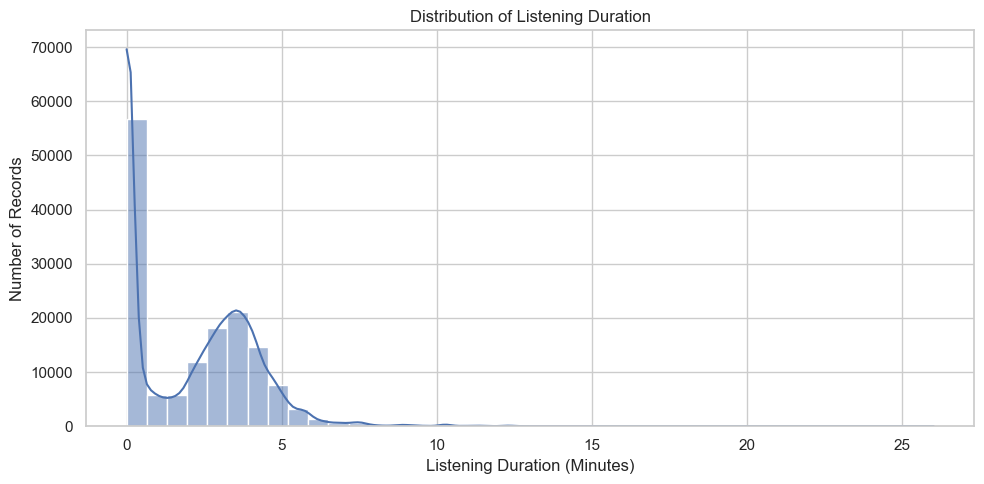

In [21]:
plt.figure(figsize=(10, 5))
sns.histplot(clean_df["duration_minutes"], bins=40, kde=True)
plt.title("Distribution of Listening Duration")
plt.xlabel("Listening Duration (Minutes)")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### Duration Threshold Analysis

In [22]:
duration_df = clean_df[clean_df["duration_minutes"] > 0].copy()

thresholds = [0.5, 1, 2, 3, 4, 5]

for threshold in thresholds:
    count = (duration_df["duration_minutes"] >= threshold).sum()
    percentage = count / len(duration_df) * 100
    print(f"{threshold}+ minutes: {count:,} records ({percentage:.2f}%)")

0.5+ minutes: 93,098 records (64.35%)
1+ minutes: 87,951 records (60.79%)
2+ minutes: 79,172 records (54.72%)
3+ minutes: 57,543 records (39.77%)
4+ minutes: 25,799 records (17.83%)
5+ minutes: 8,404 records (5.81%)


## 12. Peak Listening Hours

In [23]:
hourly_listening = clean_df["hour"].value_counts().sort_index()
hourly_listening

hour
0     10850
1      9363
2      9000
3      8460
4      6326
5      7130
6      7353
7      4403
8      2295
9      1683
10     1200
11      892
12      722
13     1617
14     2702
15     3579
16     6589
17     8946
18     8734
19     8093
20    10313
21     8783
22     8630
23    10415
Name: count, dtype: int64

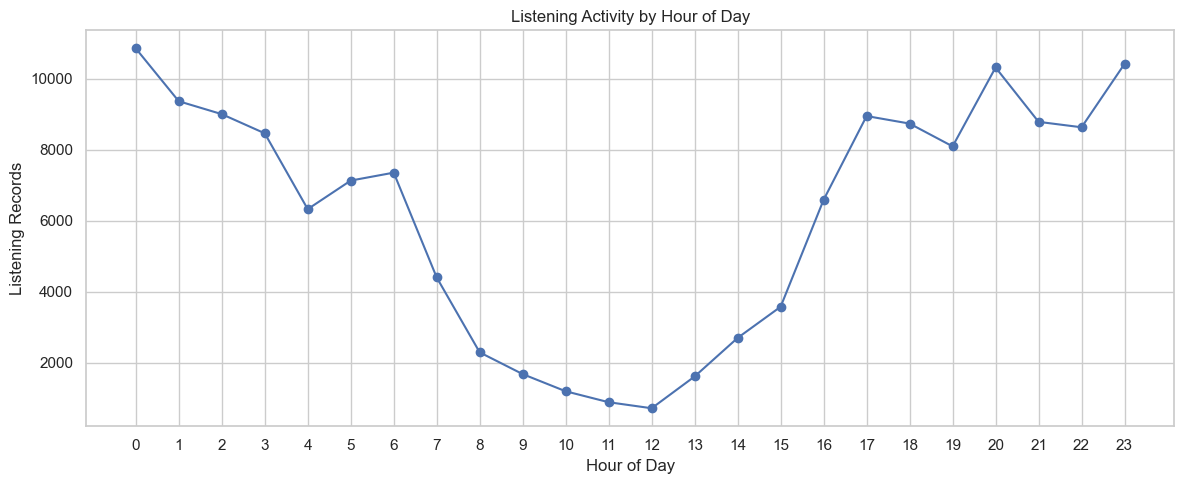

In [24]:
plt.figure(figsize=(12, 5))
hourly_listening.plot(kind="line", marker="o")
plt.title("Listening Activity by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Listening Records")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

## 13. Listening by Day of Week

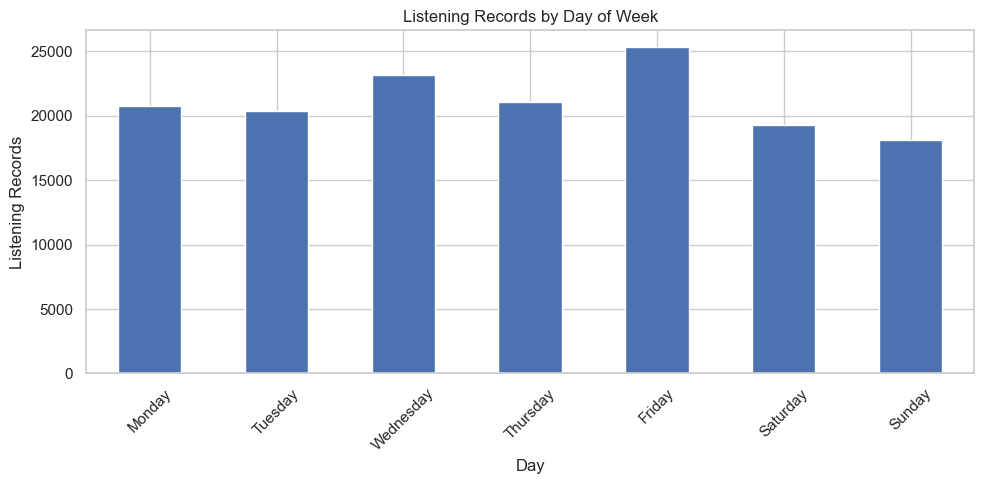

In [25]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daily_listening = clean_df["day_of_week"].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
daily_listening.plot(kind="bar")
plt.title("Listening Records by Day of Week")
plt.xlabel("Day")
plt.ylabel("Listening Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. Platform Analysis

In [26]:
platform_counts = clean_df["platform"].value_counts()
platform_counts

platform
android           139002
iOS                 3048
cast to device      2981
windows             1690
mac                 1176
web player           181
Name: count, dtype: Int64

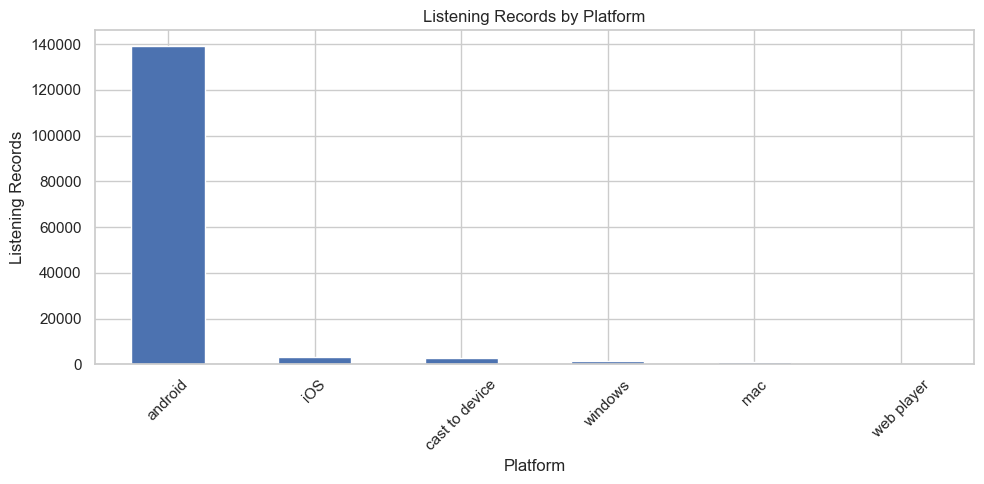

In [27]:
plt.figure(figsize=(10, 5))
platform_counts.plot(kind="bar")
plt.title("Listening Records by Platform")
plt.xlabel("Platform")
plt.ylabel("Listening Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 15. Shuffle and Skip Behavior

In [28]:
print("Shuffle distribution:")
print(clean_df["shuffle"].value_counts())

print("\nSkipped distribution:")
print(clean_df["skipped"].value_counts())

print("\nSkip rate by shuffle status:")
skip_by_shuffle = clean_df.groupby("shuffle")["skipped"].mean().mul(100).round(2)
print(skip_by_shuffle)

Shuffle distribution:
shuffle
True     111130
False     36948
Name: count, dtype: int64

Skipped distribution:
skipped
False    140216
True       7862
Name: count, dtype: int64

Skip rate by shuffle status:
shuffle
False    4.47
True     5.59
Name: skipped, dtype: float64


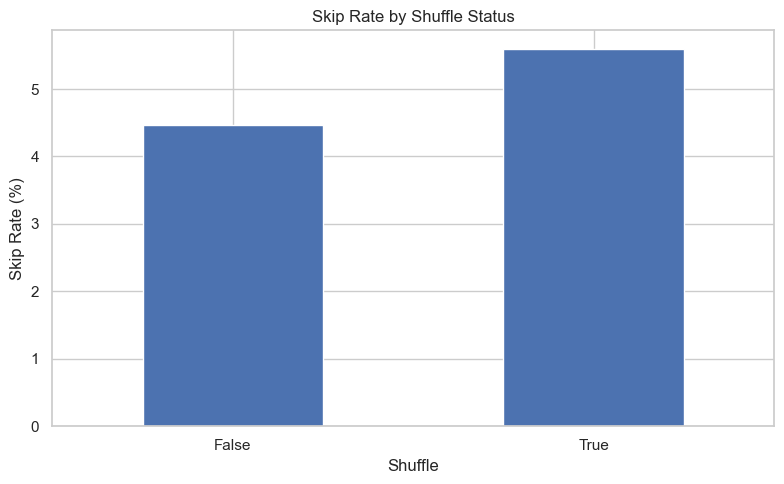

In [29]:
skip_by_shuffle.plot(kind="bar", figsize=(8, 5))
plt.title("Skip Rate by Shuffle Status")
plt.xlabel("Shuffle")
plt.ylabel("Skip Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 16. Playback Reasons

In [30]:
print("Reason Start:")
display(clean_df["reason_start"].value_counts())

print("Reason End:")
display(clean_df["reason_end"].value_counts())

Reason Start:


reason_start
trackdone     75698
fwdbtn        53458
clickrow      10849
appload        3712
backbtn        2183
playbtn        1437
remote          426
unknown         166
trackerror      120
nextbtn          21
popup             5
endplay           2
autoplay          1
Name: count, dtype: Int64

Reason End:


reason_end
trackdone                       76182
fwdbtn                          53133
endplay                          9736
logout                           4357
backbtn                          2153
unexpected-exit-while-paused     1717
unknown                           384
remote                            222
unexpected-exit                   118
clickrow                           34
nextbtn                            21
appload                             7
popup                               6
reload                              4
trackerror                          4
Name: count, dtype: Int64

## 17. Key Findings

In [31]:
most_active_year = yearly_listening.idxmax()
most_active_year_records = yearly_listening.max()

peak_hour = hourly_listening.idxmax()
peak_hour_records = hourly_listening.max()

top_artist = top_artists.index[0]
top_artist_records = top_artists.iloc[0]["listening_records"]

top_track = top_tracks.index[0]
top_track_records = top_tracks.iloc[0]["listening_records"]

print(f"• The dataset contains {total_records:,} listening records.")
print(f"• Listening history spans {clean_df['year'].min()} to {clean_df['year'].max()}.")
print(f"• The most active year was {most_active_year} with {most_active_year_records:,} records.")
print(f"• The most frequently played artist was {top_artist} with {top_artist_records:,} records.")
print(f"• The most frequently played track was {top_track[0]} by {top_track[1]} with {top_track_records:,} records.")
print(f"• The peak listening hour was {peak_hour}:00 with {peak_hour_records:,} records.")
print(f"• Average listening duration was {average_play_minutes:.2f} minutes.")
print(f"• Overall skip rate was {skip_rate:.2f}%.")

• The dataset contains 148,078 listening records.
• Listening history spans 2013 to 2024.
• The most active year was 2017 with 25,937 records.
• The most frequently played artist was The Beatles with 13,479.0 records.
• The most frequently played track was Ode To The Mets by The Strokes with 203.0 records.
• The peak listening hour was 0:00 with 10,850 records.
• Average listening duration was 2.14 minutes.
• Overall skip rate was 5.31%.


## 18. Conclusion

This analysis provides an overview of Spotify listening behavior across the available streaming history.

The project demonstrates practical skills in:

- Data loading and inspection
- Data cleaning and preprocessing
- Feature engineering with timestamps
- Aggregation and exploratory data analysis
- Statistical summaries
- Behavioral analysis
- Data visualization using Matplotlib and Seaborn

The results can be used to understand changes in listening activity over time, identify frequently played music, and examine how playback behavior varies across different conditions.